### Contextualização

#### Introdução

Este desafio utiliza o dataset [Chest X-Ray Images (Pneumonia) - Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) para estudar um problema de **classificação supervisionada de imagens médicas**. O objetivo é classificar radiografias de tórax em duas classes: **NORMAL**, quando não há sinais de pneumonia, e **PNEUMONIA**, quando a imagem apresenta indícios da doença.

O problema é relevante para a área de Reconhecimento de Padrões porque envolve a identificação de características visuais em imagens, como textura, contraste e regiões de opacidade pulmonar. Como os dados são imagens médicas, o processo exige etapas de pré-processamento, análise exploratória e avaliação do desempenho dos modelos.

O dataset é composto por radiografias torácicas pediátricas em formato JPEG, organizadas nos subconjuntos **train**, **val** e **test**, cada um contendo as classes **NORMAL** e **PNEUMONIA**. As imagens são provenientes de pacientes entre 1 e 5 anos de idade atendidos no Guangzhou Women and Children’s Medical Center, na China. Antes da disponibilização, as imagens passaram por um processo de controle de qualidade, com remoção de exames de baixa qualidade ou ilegíveis.

#### Exploração Inicial

A análise inicial dos dados mostra que o conjunto está dividido em três partes: treinamento, validação e teste. A distribuição das imagens por classe está da seguinte forma:

| Subconjunto | NORMAL | PNEUMONIA | Total |
| ----------- | -----: | --------: | ----: |
| Treino      |  1.341 |     3.875 | 5.216 |
| Validação   |      8 |         8 |    16 |
| Teste       |    234 |       390 |   624 |

Observa-se que o conjunto de treinamento é desbalanceado, com uma quantidade maior de imagens da classe **PNEUMONIA**. Esse desbalanceamento pode influenciar o treinamento dos modelos, tornando necessário o uso de métricas além da acurácia, como precisão, recall e F1-score.


In [61]:
# imports

import os
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models
from torchvision.models import MobileNet_V2_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Device: cuda
GPU: NVIDIA GeForce 940MX


In [ ]:
# settings

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
SPLIT_NAMES = ["train", "val", "test"]

MAX_EPOCHS = 20
PATIENCE = 4
LEARNING_RATE = 0.01
BATCH_SIZE = 32
NUM_WORKERS = 2
FINAL_THRESHOLD = 0.5

SPLIT_TRAIN = 0.70
SPLIT_VAL = 0.15
SPLIT_TEST = 0.15


IMG_EXTENSIONS = ".jpeg"

ORIGINAL_BEST_MODEL_PATH = f"best_mobilenetv2_original.pth"
BALANCED_BEST_MODEL_PATH = f"best_mobilenetv2_balanced.pth"

ORIGINAL_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/chest_xray")
BALANCED_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/balanced_chest_xray")

### Preparação

Na etapa de preparação dos dados, serão realizados dois experimentos com o objetivo de comparar o desempenho dos modelos em diferentes cenários de distribuição das classes.

No primeiro experimento, será utilizado o **dataset original**, mantendo a estrutura inicial dos dados e o desbalanceamento entre as classes **NORMAL** e **PNEUMONIA**. Essa abordagem permite avaliar como o modelo se comporta quando treinado com a distribuição original das imagens, na qual há uma quantidade maior de exemplos da classe **PNEUMONIA**.

No segundo experimento, será criado um **novo dataset balanceado** utilizando a técnica de **undersampling**. Essa técnica consiste em manter todos os dados da classe com menor frequência e reduzir a quantidade de amostras da classe majoritária. Dessa forma, o conjunto passa a ter uma distribuição mais equilibrada da variável alvo, evitando que o modelo favoreça excessivamente a classe mais frequente durante o treinamento.

Após o balanceamento, o novo dataset será dividido em três subconjuntos:

| Subconjunto | Proporção |
| ----------- | --------: |
| Treinamento |       70% |
| Validação   |       15% |
| Teste       |       15% |

Essa nova divisão será utilizada para treinar, validar e testar os modelos em um cenário com classes equilibradas. Com isso, será possível comparar os resultados obtidos no dataset original desbalanceado com os resultados obtidos no dataset balanceado, analisando o impacto do balanceamento no desempenho dos classificadores.


In [63]:
# faz o balanceamento do dataset original pela técnica de unsersampling, baseado na classe NORMAL que possui menos exemplos
# não precisa executar esse código toda vez, apenas quando quer criar um novo dataset balanceado

import shutil

def create_balanced_dataset():

    paths_by_label = {CLASS_NAMES[0]: [], CLASS_NAMES[1]: []}
    seen_paths = set()

    for split_name in SPLIT_NAMES:
        split_dir = ORIGINAL_DATA_ROOT / split_name

        for folder_name in CLASS_NAMES:
            class_dir = split_dir / folder_name
            if class_dir.exists() and class_dir.is_dir():
                for image_path in class_dir.rglob("*"):
                    if image_path.is_file() and image_path.suffix.lower() in IMG_EXTENSIONS:
                        resolved = image_path.resolve()
                        if resolved not in seen_paths:
                            paths_by_label[folder_name].append(image_path)
                            seen_paths.add(resolved)

    for class_name in CLASS_NAMES:
        print(f"Original {class_name}: {len(paths_by_label[class_name])}")

    min_count = min(len(paths_by_label[CLASS_NAMES[0]]), len(paths_by_label[CLASS_NAMES[1]]))

    rng = random.Random(SEED)
    selected_by_label = {
        label: rng.sample(paths_by_label[label], min_count)
        for label in CLASS_NAMES
    }

    if BALANCED_DATA_ROOT.exists():
        shutil.rmtree(BALANCED_DATA_ROOT)

    for split_name in SPLIT_NAMES:
        for class_name in CLASS_NAMES:
            (BALANCED_DATA_ROOT / split_name / class_name).mkdir(parents=True, exist_ok=True)

    split_pairs = {SPLIT_NAMES[0]: [], SPLIT_NAMES[1]: [], SPLIT_NAMES[2]: []}

    for class_name in CLASS_NAMES:
        selected_paths = selected_by_label[class_name]

        train_paths, temp_paths = train_test_split(
            selected_paths,
            train_size=SPLIT_TRAIN,
            random_state=SEED
        )

        val_paths, test_paths = train_test_split(
            temp_paths,
            test_size=0.50,
            random_state=SEED
        )

        split_pairs[SPLIT_NAMES[0]].extend((path, class_name) for path in train_paths)
        split_pairs[SPLIT_NAMES[1]].extend((path, class_name) for path in val_paths)
        split_pairs[SPLIT_NAMES[2]].extend((path, class_name) for path in test_paths)

    for split_name, pairs in split_pairs.items():
        for i, (image_path, class_name) in enumerate(pairs):
            dst_name = f"{class_name}_{split_name}_{i}_{image_path.name}"
            shutil.copy2(image_path, BALANCED_DATA_ROOT / split_name / class_name / dst_name)

    print("Balanced dataset created successfully in:", BALANCED_DATA_ROOT)

    for split_name in ["train", "val", "test"]:
        print("|",split_name.upper())
        total = 0
        for class_name in CLASS_NAMES:
            n = len(list((BALANCED_DATA_ROOT / split_name / class_name).glob("*")))
            total += n
            print("|--",class_name, ":", n)
        print("Total", split_name, ":", total)

# quando for necessário recriar o balanced dataset, descomentar essa chamada        
#create_balanced_dataset()

In [64]:
# Classe que representa o dataset

class ChestXRayDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.classes = CLASS_NAMES
        self.class_to_idx = {
            class_name: idx for idx, class_name in enumerate(self.classes)
        }

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label
    
# funcoes para montar os datasets de treino, validação e teste
def read_samples_by_folder(data_root, split_name):
    split_dir = Path(data_root) / split_name

    samples = []
    seen_paths = set()

    for label in CLASS_NAMES:
        class_dir = split_dir / label

        for image_path in class_dir.rglob("*"):
            if image_path.is_file() and image_path.suffix.lower() in IMG_EXTENSIONS:
                resolved = image_path.resolve()
                
                if resolved not in seen_paths:
                    samples.append((str(image_path), CLASS_NAMES.index(label)))
                    seen_paths.add(resolved)
                    
    samples = sorted(samples, key=lambda x: x[0])
    return samples

def print_class_counts(name, samples):
    counts = Counter(label for _, label in samples)

    print(f"{name} images:", len(samples))
    print(f"|--NORMAL:", counts.get(0, 0))
    print(f"|--PNEUMONIA:", counts.get(1, 0))

In [65]:
original_train_samples = read_samples_by_folder(ORIGINAL_DATA_ROOT, "train")
original_val_samples = read_samples_by_folder(ORIGINAL_DATA_ROOT, "val")
original_test_samples = read_samples_by_folder(ORIGINAL_DATA_ROOT, "test")

print("split: 70% Train / 15% Validation / 15% Test")
print_class_counts("Train", original_train_samples)
print_class_counts("Validation", original_val_samples)
print_class_counts("Test", original_test_samples)

total_images = len(original_train_samples) + len(original_val_samples) + len(original_test_samples)
print("Total images used:", total_images)

split: 70% Train / 15% Validation / 15% Test
Train images: 5216
|--NORMAL: 1341
|--PNEUMONIA: 3875
Validation images: 16
|--NORMAL: 8
|--PNEUMONIA: 8
Test images: 624
|--NORMAL: 234
|--PNEUMONIA: 390
Total images used: 5856


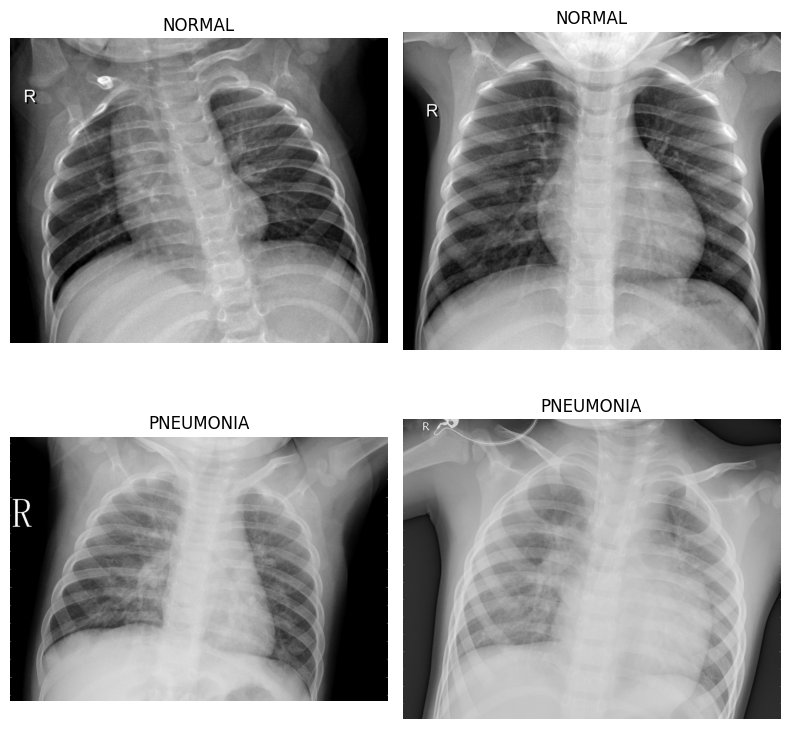

In [66]:
# Cell 7 — Show sample images

def show_sample_images(samples, n_per_class=2):
    fig, axes = plt.subplots(
        len(CLASS_NAMES),
        n_per_class,
        figsize=(4 * n_per_class, 4 * len(CLASS_NAMES))
    )

    for class_name in CLASS_NAMES:
        class_idx = CLASS_NAMES.index(class_name)
        class_samples = [path for path, y in samples if y == class_idx]

        if len(class_samples) == 0:
            continue

        chosen_paths = random.sample(
            class_samples,
            min(n_per_class, len(class_samples))
        )

        for i, image_path in enumerate(chosen_paths):
            image = Image.open(image_path)
            axes[class_idx, i].imshow(image, cmap="gray")
            axes[class_idx, i].set_title(class_name)
            axes[class_idx, i].axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images(original_train_samples, n_per_class=2)

### Aplicação das Técnicas de Aprendizado de Máquina

Para a etapa de classificação foi adotada uma abordagem baseada em redes neurais convolucionais, por serem modelos adequados para tarefas de reconhecimento de padrões em imagens. Esse tipo de arquitetura permite a extração automática de características visuais relevantes, como bordas, texturas, formas e padrões locais, reduzindo a necessidade de definição manual de atributos.

O modelo escolhido foi o MobileNetV2, uma arquitetura eficiente, projetada para apresentar bom desempenho com baixo custo computacional. Sua utilização é adequada ao problema proposto, pois combina capacidade de extração de características com leveza em termos de número de parâmetros e operações, tornando o treinamento e a inferência mais viáveis mesmo em ambientes com recursos limitados.

Neste trabalho, foi utilizado o modelo MobileNetV2 com pesos pré-treinados disponibilizados pelo PyTorch/TorchVision. Esses pesos foram originalmente treinados sobre o conjunto ImageNet, permitindo o uso de aprendizado por transferência. Dessa forma, as camadas iniciais do modelo já possuem filtros capazes de identificar padrões visuais genéricos, enquanto as camadas finais podem ser adaptadas para a tarefa específica de classificação entre imagens normais e imagens com pneumonia.

Além disso, foi aplicado o pré-processamento padrão associado aos pesos pré-treinados do MobileNetV2 no TorchVision. Esse procedimento inclui o redimensionamento da imagem, seguido de um recorte central para a dimensão de entrada esperada pelo modelo, principalmente ajustando as imagens para 224 × 224 pixels. Em seguida, os valores dos pixels são reescalados e normalizados com médias e desvios-padrão compatíveis com o treinamento original no ImageNet.

A documentação indica que MobileNet_V2_Weights.DEFAULT corresponde aos pesos IMAGENET1K_V2, com cerca de 3,5 milhões de parâmetros, 0,30 GFLOPS e tamanho aproximado de 13,6 MB. Para esses pesos, as transformações fazem resize com crop central para 224 pixels e normalização com mean=[0.485, 0.456, 0.406] e std=[0.229, 0.224, 0.225].


In [67]:

weights = MobileNet_V2_Weights.DEFAULT
preprocess = weights.transforms()

original_train_dataset = ChestXRayDataset(original_train_samples, transform=preprocess)
original_val_dataset = ChestXRayDataset(original_val_samples, transform=preprocess)
original_test_dataset = ChestXRayDataset(original_test_samples, transform=preprocess)

print("Dimensões da imagem após transformação:", original_train_dataset[0][0].shape)

Dimensões da imagem após transformação: torch.Size([3, 224, 224])


A classe `Dataset` armazena as amostras e seus labels correspondentes, e `DataLoader` envolve o `Dataset` em um iterável para permitir acesso fácil às amostras. Os seguinte parâmetros são utilizados:

`dataset` (`Dataset`) – conjunto de dados a partir do qual os dados serão carregados.

`batch_size` (`int`, opcional) – quantas amostras carregar por lote/batch. Padrão: `1`.

`shuffle` (`bool`, opcional) – defina como `True` para que os dados sejam embaralhados novamente a cada época. Padrão: `False`.

`num_workers` (`int`, opcional) – quantos subprocessos usar para o carregamento dos dados. `0` significa que os dados serão carregados no processo principal. Padrão: `0`.

`pin_memory` (`bool`, opcional) – se `True`, o data loader copiará os Tensores para memória fixada do dispositivo/CUDA antes de retorná-los.

In [68]:
pin_memory = torch.cuda.is_available()

original_train_loader = DataLoader(
    original_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

original_val_loader = DataLoader(
    original_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

original_test_loader = DataLoader(
    original_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

Faz transfer learning com a MobileNetV2: carrega um modelo pré-treinado, congela suas camadas principais e substitui a camada final para adaptar o modelo à classificação binária entre raio-X normal e raio-X com pneumonia.

A última camada é trocada por uma camada linear com apenas 1 neurônio de saída.

In [69]:
model = models.mobilenet_v2(weights=weights)
for param in model.parameters():
    param.requires_grad = False
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)

model = model.to(device)


trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

Trainable parameters: 1281
Total parameters: 2225153


### Treinamento da RN no dataset original

O *early stopping* interrompe o treinamento quando a perda não melhora por várias épocas.

Neste notebook:

- `MAX_EPOCHS = 20`
- `PATIENCE = 4` (Quantas épocas sem melhoria esperar)

O melhor modelo é salvo automaticamente.

`BCEWithLogitsLoss`: a função de perda usada para medir o erro do modelo. É adequada para classificação binária pois ombina duas etapas em uma só: sigmoid + binary cross-entropy.

`Adam`: o otimizador responsável por atualizar os pesos treináveis do modelo durante o treinamento. É uma variação eficiente do gradiente descendente.

In [70]:

def get_pos_weight(train_dataset):
    train_labels = [label for _, label in train_dataset.samples]
    counter = Counter(train_labels)

    normal_count = counter.get(0, 0)
    pneumonia_count = counter.get(1, 0)

    pos_weight_value = normal_count / max(pneumonia_count, 1)

    print("Train NORMAL:", normal_count)
    print("Train PNEUMONIA:", pneumonia_count)
    print("pos_weight:", pos_weight_value)

    return torch.tensor([pos_weight_value], dtype=torch.float32).to(device)


def evaluate_during_training(model, data_loader, criterion):
    model.eval()

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1).float()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            predictions = torch.sigmoid(outputs).round()

            batch_size_current = labels.size(0)
            running_loss += loss.item() * batch_size_current
            running_corrects += torch.sum(predictions == labels).item()
            total_samples += batch_size_current

    epoch_loss = running_loss / max(total_samples, 1)
    epoch_accuracy = running_corrects / max(total_samples, 1)

    return epoch_loss, epoch_accuracy


def train_model(
    model,
    train_loader,
    val_loader,
    train_dataset,
    num_epochs=20,
    learning_rate=0.001,
    patience=4,
    best_model_path="best_model.pth"
):
    pos_weight = get_pos_weight(train_dataset)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )

    amp_enabled = torch.cuda.is_available()
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    epochs_without_improvement = 0
    best_epoch = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1).float()

            optimizer.zero_grad()

            with torch.amp.autocast("cuda", enabled=amp_enabled):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            predictions = torch.sigmoid(outputs).round()

            batch_size_current = labels.size(0)
            running_loss += loss.item() * batch_size_current
            running_corrects += torch.sum(predictions == labels).item()
            total_samples += batch_size_current

        train_loss = running_loss / max(total_samples, 1)
        train_accuracy = running_corrects / max(total_samples, 1)

        val_loss, val_accuracy = evaluate_during_training(
            model=model,
            data_loader=val_loader,
            criterion=criterion
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch [{epoch+1}/{num_epochs}], "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved at epoch {best_epoch}.")
        else:
            epochs_without_improvement += 1
            print(f"No improvement for {epochs_without_improvement} epoch(s).")

        if epochs_without_improvement >= patience:
            print("Early stopping activated.")
            break

    training_time_seconds = time.time() - start_time
    epochs_done = len(history["train_loss"])

    print("Training complete.")
    print(f"Best epoch: {best_epoch}")
    print(f"Training time: {training_time_seconds:.2f} seconds")
    print(f"Training time: {training_time_seconds/60:.2f} minutes")

    return history, training_time_seconds, best_epoch, epochs_done

In [71]:
# Inicia o treinamento

o_history, o_training_time_seconds, o_best_epoch, o_epochs_done = train_model(
    model=model,
    train_loader=original_train_loader,
    val_loader=original_val_loader,
    train_dataset=original_train_dataset,
    num_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE,
    best_model_path=ORIGINAL_BEST_MODEL_PATH
)

Train NORMAL: 1341
Train PNEUMONIA: 3875
pos_weight: 0.3460645161290323
Epoch [1/20], Train Loss: 0.1117, Train Acc: 0.9015, Val Loss: 0.3008, Val Acc: 0.8125
Best model saved at epoch 1.
Epoch [2/20], Train Loss: 0.0741, Train Acc: 0.9400, Val Loss: 0.1558, Val Acc: 1.0000
Best model saved at epoch 2.
Epoch [3/20], Train Loss: 0.0708, Train Acc: 0.9456, Val Loss: 0.1535, Val Acc: 0.9375
Best model saved at epoch 3.
Epoch [4/20], Train Loss: 0.0692, Train Acc: 0.9404, Val Loss: 0.2221, Val Acc: 0.8750
No improvement for 1 epoch(s).
Epoch [5/20], Train Loss: 0.0606, Train Acc: 0.9480, Val Loss: 0.1838, Val Acc: 0.8750
No improvement for 2 epoch(s).
Epoch [6/20], Train Loss: 0.0632, Train Acc: 0.9486, Val Loss: 0.1239, Val Acc: 0.9375
Best model saved at epoch 6.
Epoch [7/20], Train Loss: 0.0659, Train Acc: 0.9465, Val Loss: 0.3499, Val Acc: 0.8125
No improvement for 1 epoch(s).
Epoch [8/20], Train Loss: 0.0645, Train Acc: 0.9505, Val Loss: 0.2046, Val Acc: 0.8750
No improvement for 2 ep

### Avaliação dos Resultados

Exibe as curvas de treinamento:

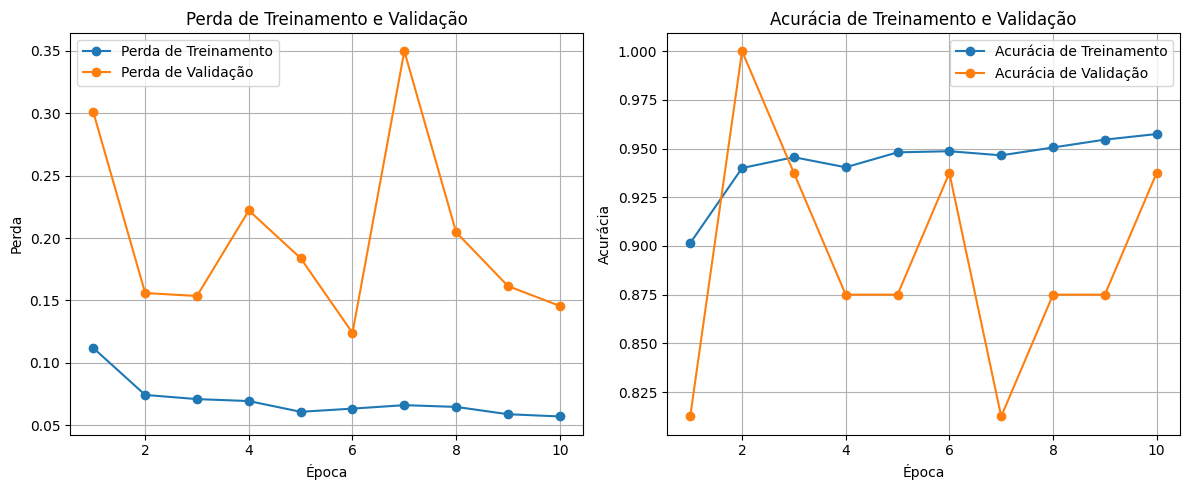

In [72]:
o_epochs = range(1, len(o_history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(o_epochs, o_history["train_loss"], marker="o", label="Perda de Treinamento")
plt.plot(o_epochs, o_history["val_loss"], marker="o", label="Perda de Validação")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.title("Perda de Treinamento e Validação")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(o_epochs, o_history["train_accuracy"], marker="o", label="Acurácia de Treinamento")
plt.plot(o_epochs, o_history["val_accuracy"], marker="o", label="Acurácia de Validação")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Acurácia de Treinamento e Validação")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Carrega o melhor modelo que foi salvo em arquivo:

In [73]:
model.load_state_dict(torch.load(ORIGINAL_BEST_MODEL_PATH, map_location=device))
model = model.to(device)

print("Loaded best model:", ORIGINAL_BEST_MODEL_PATH)

Loaded best model: best_mobilenetv2_original.pth


/tmp/ipykernel_10906/1625859462.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ORIGINAL_BEST_MODEL_PATH, map_location=device))


A avaliação dos resultados é feita no conjunto de testes:

Obs.: o threshold é o valor de corte usado para transformar a probabilidade calculada pela rede (entre 0 e 1) em uma decisão final (Pneumonia ou não).

In [74]:
def evaluate_model(model, test_loader, threshold=0.5):
    model.eval()

    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)

            outputs = model(inputs)
            probabilities = torch.sigmoid(outputs).squeeze(1).cpu()
            predictions = (probabilities >= threshold).long()

            all_probabilities.extend(probabilities.tolist())
            all_predictions.extend(predictions.tolist())
            all_labels.extend(labels.tolist())

    test_accuracy = accuracy_score(all_labels, all_predictions)
    test_precision = precision_score(all_labels, all_predictions, zero_division=0)
    test_recall = recall_score(all_labels, all_predictions, zero_division=0)
    test_f1 = f1_score(all_labels, all_predictions, zero_division=0)

    print(f"Threshold: {threshold}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1 Score: {test_f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_predictions,
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

    results = {
        "model": "mobilenetv2",
        "threshold": threshold,
        "accuracy": test_accuracy,
        "precision": test_precision,
        "recall": test_recall,
        "f1_score": test_f1,
        "max_epochs": MAX_EPOCHS,
        "epochs_done": o_epochs_done,
        "best_epoch": o_best_epoch,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "patience": PATIENCE,
        "training_time_seconds": o_training_time_seconds,
        "training_time_minutes": o_training_time_seconds / 60,
        "train_images": len(original_train_dataset),
        "val_images": len(original_val_dataset),
        "test_images": len(original_test_dataset),
        "best_model_path": ORIGINAL_BEST_MODEL_PATH,
    }

    return all_labels, all_predictions, all_probabilities, results


o_all_labels, o_all_predictions, o_all_probabilities, o_results = evaluate_model(
    model,
    original_test_loader,
    threshold=FINAL_THRESHOLD
)

Threshold: 0.5
Test Accuracy: 0.8750
Test Precision: 0.8578
Test Recall: 0.9590
Test F1 Score: 0.9056

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.74      0.82       234
   PNEUMONIA       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624



##### Matriz de confusão

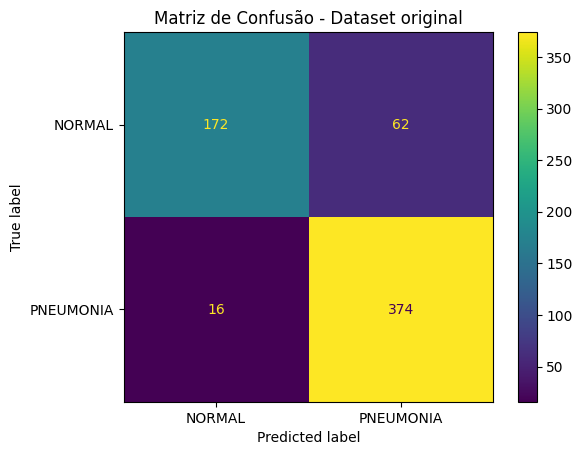

In [75]:
o_conf_matrix = confusion_matrix(o_all_labels, o_all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=o_conf_matrix,
    display_labels=CLASS_NAMES
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão - Dataset original")
plt.show()

### Treinamento da RN no dataset balanceado

In [76]:
balanced_train_samples = read_samples_by_folder(BALANCED_DATA_ROOT, "train")
balanced_val_samples = read_samples_by_folder(BALANCED_DATA_ROOT, "val")
balanced_test_samples = read_samples_by_folder(BALANCED_DATA_ROOT, "test")

print("split: 70% Train / 15% Validation / 15% Test")
print_class_counts("Train", balanced_train_samples)
print_class_counts("Validation", balanced_val_samples)
print_class_counts("Test", balanced_test_samples)

total_balanced_images = len(balanced_train_samples) + len(balanced_val_samples) + len(balanced_test_samples)
print("Total images used:", total_balanced_images)

split: 70% Train / 15% Validation / 15% Test
Train images: 2216
|--NORMAL: 1108
|--PNEUMONIA: 1108
Validation images: 474
|--NORMAL: 237
|--PNEUMONIA: 237
Test images: 476
|--NORMAL: 238
|--PNEUMONIA: 238
Total images used: 3166


In [77]:

weights = MobileNet_V2_Weights.DEFAULT
preprocess = weights.transforms()

balanced_train_dataset = ChestXRayDataset(balanced_train_samples, transform=preprocess)
balanced_val_dataset = ChestXRayDataset(balanced_val_samples, transform=preprocess)
balanced_test_dataset = ChestXRayDataset(balanced_test_samples, transform=preprocess)

In [78]:
balanced_train_loader = DataLoader(
    balanced_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

balanced_val_loader = DataLoader(
    balanced_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

balanced_test_loader = DataLoader(
    balanced_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

In [79]:
model = models.mobilenet_v2(weights=weights)
for param in model.parameters():
    param.requires_grad = False
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)

model = model.to(device)


trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

In [80]:
# Inicia o treinamento

b_history, b_training_time_seconds, b_best_epoch, b_epochs_done = train_model(
    model=model,
    train_loader=balanced_train_loader,
    val_loader=balanced_val_loader,
    train_dataset=balanced_train_dataset,
    num_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE,
    best_model_path=BALANCED_BEST_MODEL_PATH
)

Train NORMAL: 1108
Train PNEUMONIA: 1108
pos_weight: 1.0
Epoch [1/20], Train Loss: 0.2930, Train Acc: 0.8755, Val Loss: 0.1644, Val Acc: 0.9430
Best model saved at epoch 1.
Epoch [2/20], Train Loss: 0.2177, Train Acc: 0.9138, Val Loss: 0.2092, Val Acc: 0.9262
No improvement for 1 epoch(s).
Epoch [3/20], Train Loss: 0.1976, Train Acc: 0.9273, Val Loss: 0.2472, Val Acc: 0.9114
No improvement for 2 epoch(s).
Epoch [4/20], Train Loss: 0.2614, Train Acc: 0.9052, Val Loss: 0.1485, Val Acc: 0.9515
Best model saved at epoch 4.
Epoch [5/20], Train Loss: 0.1753, Train Acc: 0.9305, Val Loss: 0.1671, Val Acc: 0.9388
No improvement for 1 epoch(s).
Epoch [6/20], Train Loss: 0.1706, Train Acc: 0.9359, Val Loss: 0.2102, Val Acc: 0.9283
No improvement for 2 epoch(s).
Epoch [7/20], Train Loss: 0.1693, Train Acc: 0.9296, Val Loss: 0.1422, Val Acc: 0.9515
Best model saved at epoch 7.
Epoch [8/20], Train Loss: 0.1394, Train Acc: 0.9477, Val Loss: 0.1577, Val Acc: 0.9409
No improvement for 1 epoch(s).
Epoch

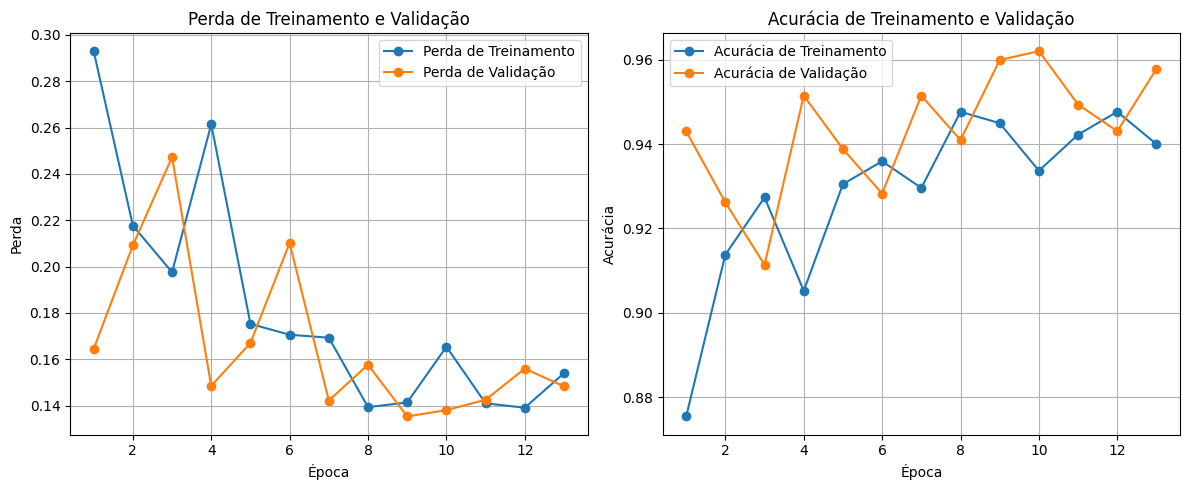

In [81]:
b_epochs = range(1, len(b_history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(b_epochs, b_history["train_loss"], marker="o", label="Perda de Treinamento")
plt.plot(b_epochs, b_history["val_loss"], marker="o", label="Perda de Validação")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.title("Perda de Treinamento e Validação")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(b_epochs, b_history["train_accuracy"], marker="o", label="Acurácia de Treinamento")
plt.plot(b_epochs, b_history["val_accuracy"], marker="o", label="Acurácia de Validação")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Acurácia de Treinamento e Validação")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [82]:
model.load_state_dict(torch.load(BALANCED_BEST_MODEL_PATH, map_location=device))
model = model.to(device)

print("Loaded best model:", BALANCED_BEST_MODEL_PATH)

b_all_labels, b_all_predictions, b_all_probabilities, b_results = evaluate_model(
    model,
    balanced_test_loader,
    threshold=FINAL_THRESHOLD
)

/tmp/ipykernel_10906/1397209888.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BALANCED_BEST_MODEL_PATH, map_location=device))


Loaded best model: best_mobilenetv2_balanced.pth
Threshold: 0.5
Test Accuracy: 0.9370
Test Precision: 0.9160
Test Recall: 0.9622
Test F1 Score: 0.9385

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.91      0.94       238
   PNEUMONIA       0.92      0.96      0.94       238

    accuracy                           0.94       476
   macro avg       0.94      0.94      0.94       476
weighted avg       0.94      0.94      0.94       476



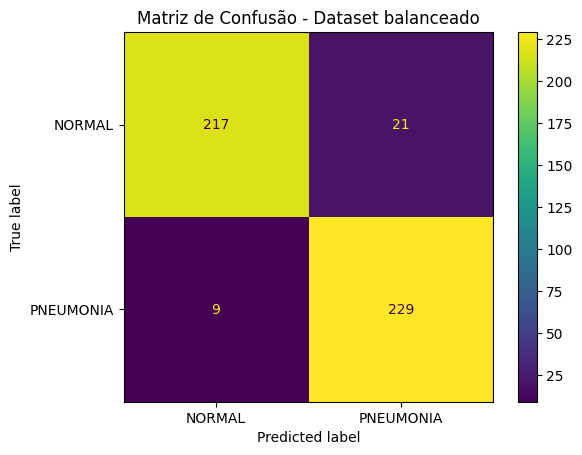

In [83]:
b_conf_matrix = confusion_matrix(b_all_labels, b_all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=b_conf_matrix,
    display_labels=CLASS_NAMES
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão - Dataset balanceado")
plt.show()

### Conclusão

As métricas avaliam o quanto essas previsões estão corretas.

`Acurácia`: De todas as imagens do conjunto de teste, quantas foram classificadas corretamente?

`Precisão`: Quando o modelo diz que uma imagem é pneumonia, com que frequência ele está certo?

`Recall (sensibilidade)`: De todos os casos reais de pneumonia, quantos o modelo conseguiu detectar?

`F1-score`: A média harmônica entre precisão e recall. Um F1-score alto indica que o modelo consegue, ao mesmo tempo, detectar bem os casos positivos e evitar muitos falsos positivos.

Os resultados dos dois experimentos foram:

**Experimento 1 — Dataset desbalanceado**

O modelo apresentou um desempenho muito bom para a classe PNEUMONIA, enquanto o desempenho para a classe NORMAL foi inferior.
O modelo ficou mais sensível à classe PNEUMONIA. Isso é esperado em um cenário de treinamento desbalanceado,

| Classe       | Precisão  | Recall | F1-score |
| ------------ | --------: | -----: | -------: |
| NORMAL       |      0.91 |   0.74 |     0.82 |
| PNEUMONIA    |      0.86 |   0.96 |     0.91 |
| Acurácia     |           |        |     0.88 |
| Média Macro  |      0.89 |   0.85 |     0.86 |
| Média Pond.  |      0.88 |   0.88 |     0.87 |


**Experimento 2 — Dataset balanceado**

A acurácia subiu de 0.8750 para 0.9370, indicando que o modelo passou a classificar corretamente uma proporção maior das imagens.
Além disso, o desempenho ficou mais equilibrado entre as classes. 
A maior melhora foi no recall da classe NORMAL, que passou de 0.74 para 0.91. Isso mostra que, após o balanceamento, o modelo passou a reconhecer exames sem pneumonia com muito mais eficiência.

| Classe       | Precisão  | Recall | F1-score |
| ------------ | --------: | -----: | -------: |
| NORMAL       |      0.96 |   0.91 |     0.94 |
| PNEUMONIA    |      0.92 |   0.96 |     0.94 |
| Acurácia     |           |        |     0.94 |
| Média Macro  |      0.94 |   0.94 |     0.94 |
| Média Pond.  |      0.94 |   0.94 |     0.94 |

**Comparação geral entre os experimentos**

O segundo experimento apresentou melhores resultados em todas as métricas:

| Métrica geral | Dataset desbalanceado | Dataset balanceado |
| ------------- | --------------------: | -----------------: |
| Acurácia      |                0.8750 |             0.9370 |
| Precisão      |                0.8578 |             0.9160 |
| Recall        |                0.9590 |             0.9622 |
| F1-score      |                0.9056 |             0.9385 |

**Conclusão**

O experimento com dataset balanceado apresentou melhor desempenho geral e maior equilíbrio entre as classes. Enquanto o modelo treinado com dados desbalanceados mostrou tendência a favorecer a classe PNEUMONIA, o modelo balanceado conseguiu melhorar substancialmente a classificação da classe NORMAL sem comprometer a detecção dos casos de pneumonia. Dessa forma, o balanceamento dos dados contribuiu para uma classificação mais confiável.


